# Editing Graph State
## Review
We discussed motivations for human-in-the-loop:
1. `Approval` - We can interrupt our agent, surface state to a user, and allow the user to accept an action.
2. `Debugging` - We can rewind the graph to reproduce or avoid issues.
3. `Editing` - You can modify the state.

We showed how breakpoints support user approval, but don't yet know how to modify our graph state once our graph is interrupted.

## Goals
Now, let's show how to directly edit the graph state and insert human feedback.

## Editing State
Previously, we introduced breakpoints. We used them to interrupt the graph and await user approval before executing the next node. But breakpoints are also opportunities to modify the graph state.

Let's set up our agent with a breakpoint before the `assistant` node.

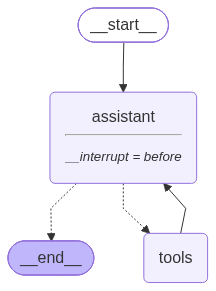

In [7]:
# Import libraries
import os, getpass
from dotenv import load_dotenv
from IPython.display import Image, display

from langgraph.graph import MessagesState,StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage

# Load env variable for API Key
load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")

# Set the Chat Model
llm = ChatOpenAI(
    model="deepseek-v4-pro",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0
)

def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.
    """
    return a * b

def add(a: int, b: int) -> int:
    """
    Adds a and b.
    """
    return a + b

def divide(a: int, b: int) -> float:
    """
    Divide a by b.
    """
    return a / b

tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools)

# System Message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

# Display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

We can see the graph is interrupted before the chat model responds. 

Now, we can directly apply a state update. Remember, updates the `messages` key will use the `add_messages` reducer:
- If we want to over-write the existing message, we can supply the message `id`.
- If we simply want to append to our list of messages, then we can pass a message without an `id` specified, as shown below.

In [8]:
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

graph.update_state(
    thread,
    {"messages": [HumanMessage(content="No, actually multiply 3 and 3.")]},
)
new_state = graph.get_state(thread).values
for m in new_state["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No, actually multiply 3 and 3.


Now, let's proceed with our agent, simply by passing `None` and allowing it proceed from the current state.

We emit the current and then proceed to execute the remaining nodes.

In [9]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

No, actually multiply 3 and 3.
================================== Ai Message ==================================
Tool Calls:
  multiply (call_00_u3Qlr2DMUQZ3UF3MfAH91783)
 Call ID: call_00_u3Qlr2DMUQZ3UF3MfAH91783
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: multiply

9


Now, we're back at the `assistant`, which has our `breakpoint`. We can again pass `None` to proceed.

In [10]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

9
================================== Ai Message ==================================

3 × 3 = **9**.
